# 👁️ Multi-Modal Vision with Claude Sonnet 4.6

Welcome to **PrecisionTech**, a manufacturer of electronic components that wants AI to help in two places where humans often become the bottleneck:

1. **Visual quality inspection** on the production line — spotting defects before products ship.
2. **Business document analysis** in accounting — turning invoices and receipts into structured data.

In this notebook, you'll learn how to:

- Send images to Claude through Microsoft Foundry
- Use both `Content.from_data()` and `Content.from_uri()`
- Extract structured data from document images
- Compare multiple images in a single request
- Write better prompts so Claude gives useful visual insights, not just generic descriptions

Think of this notebook as a guided factory tour: first the inspection station, then the back office, all powered by the same model.


In [1]:
import os
import base64
import io
from pathlib import Path

import requests
from dotenv import load_dotenv
from agent_framework import Agent, Message, Content
from agent_framework.foundry import AnthropicFoundryClient
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as IPImage

load_dotenv(dotenv_path="../.env")

chat_client = AnthropicFoundryClient(
    model=os.environ["FOUNDRY_MODEL_DEPLOYMENT"],
    api_key=os.environ["FOUNDRY_API_KEY"],
    base_url=os.environ["FOUNDRY_ENDPOINT"],
)

agent = Agent(
    client=chat_client,
    name="vision-agent",
    instructions=(
        "You are PrecisionTech's visual analyst. Explain what you see clearly, "
        "highlight business-relevant details, and prefer structured answers when asked."
    ),
)

session = agent.create_session()
assets_dir = Path("generated_vision_assets")
assets_dir.mkdir(exist_ok=True)


def get_font(size=24):
    try:
        return ImageFont.truetype("DejaVuSans.ttf", size)
    except OSError:
        return ImageFont.load_default()


def pil_to_png_bytes(image):
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return buffer.getvalue()


def save_image(image, filename):
    path = assets_dir / filename
    image.save(path)
    return path


def preview_base64(data, chars=40):
    return base64.b64encode(data)[:chars].decode("utf-8")

warmup_message = Message(
    role="user",
    contents=[Content.from_text("Reply with READY and one sentence about why vision models matter in manufacturing.")],
)

warmup_response = await agent.run(warmup_message, session=session)
print(warmup_response.text)


<frozen abc>:106: ExperimentalWarning: [HARNESS] MemoryStore is experimental and may change or be removed in future versions without notice.
<frozen abc>:106: ExperimentalWarning: [SKILLS] SkillResource is experimental and may change or be removed in future versions without notice.


**READY**

Vision models matter in manufacturing because they enable real-time, high-accuracy defect detection and quality control at scale — far surpassing the speed and consistency of manual inspection.


## 📸 How Claude "Sees" Images

Imagine you're describing a painting to a friend on the phone — you'd say *"there's a red barn on the left, green hills behind it, a blue sky with wispy clouds."* Claude does the **reverse**: it receives the raw pixels and builds that rich understanding internally.

But unlike a phone call, Claude can also:

- read text inside images
- understand charts and diagrams
- notice anomalies and defects
- connect what it sees to your instructions

There are two common ways to send images:

- **`Content.from_data()`** → when you already have the image bytes locally (file, camera feed, generated image, download)
- **`Content.from_uri()`** → when the image already lives at a web URL

We'll start with raw bytes because that's the most common pattern in production systems.


Base64 preview of image bytes: iVBORw0KGgoAAAANSUhEUgAAArwAAAGkCAIAAABc


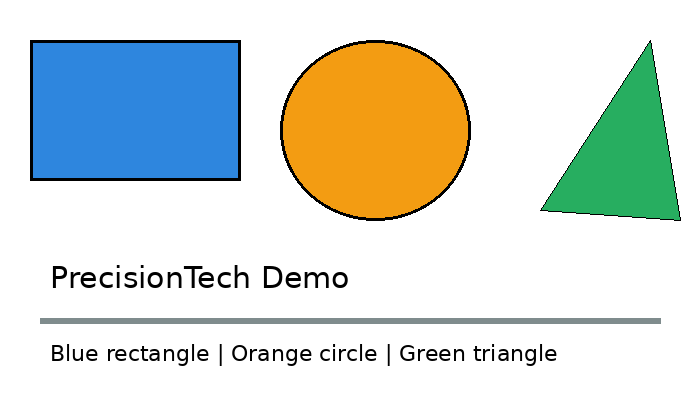

## Image Analysis — PrecisionTech Demo

### Shapes & Colors
| Shape | Color | Position |
|-------|-------|----------|
| Rectangle | Blue | Left |
| Circle | Orange | Center |
| Triangle | Green | Right |

### Layout
- Three geometric shapes are arranged **horizontally across the upper portion** of the image, evenly spaced on a white background
- All shapes have a thin **dark outline/border**
- The shapes are approximately equal in visual weight/size

### Text
- **Header:** *"PrecisionTech Demo"* — displayed in bold, clean sans-serif font below the shapes
- **Caption/Label:** *"Blue rectangle | Orange circle | Green triangle"* — descriptive text separated by a **horizontal gray divider line**, confirming the shape identities

### Business Relevance
This appears to be a **calibration or demo slide** — the kind used to:
- ✅ Test shape/color detection accuracy
- ✅ Validate vision model recognition capabilities
- ✅ Demonstrate basic object classification to stakeholders

The image label tex

In [2]:
test_image = Image.new("RGB", (700, 420), "white")
draw = ImageDraw.Draw(test_image)

draw.rectangle((30, 40, 240, 180), fill="#2E86DE", outline="black", width=3)
draw.ellipse((280, 40, 470, 220), fill="#F39C12", outline="black", width=3)
draw.polygon([(540, 210), (650, 40), (680, 220)], fill="#27AE60", outline="black")
draw.line((40, 320, 660, 320), fill="#7F8C8D", width=6)
draw.text((50, 260), "PrecisionTech Demo", fill="black", font=get_font(30))
draw.text((50, 340), "Blue rectangle | Orange circle | Green triangle", fill="black", font=get_font(22))

test_image_path = save_image(test_image, "01-geometric-test.png")
test_image_bytes = pil_to_png_bytes(test_image)

print("Base64 preview of image bytes:", preview_base64(test_image_bytes))
display(IPImage(filename=str(test_image_path)))

message = Message(
    role="user",
    contents=[
        Content.from_data(data=test_image_bytes, media_type="image/png"),
        Content.from_text("What do you see in this image? Describe the layout, colors, shapes, and any text you can read."),
    ],
)

response = await agent.run(message, session=session)
print(response.text)


## 🏭 Quality Inspection — Spotting Defects

On PrecisionTech's production line, every circuit board needs inspection. Human inspectors are skilled, but they also get tired, miss subtle flaws, and can only inspect one board at a time.

A good vision prompt works like a checklist you hand to a quality engineer. Instead of asking *"Is this okay?"*, ask for specific inspection criteria such as:

- surface defects
- color consistency
- alignment issues
- pass/fail recommendation

The clearer the checklist, the more actionable the result.


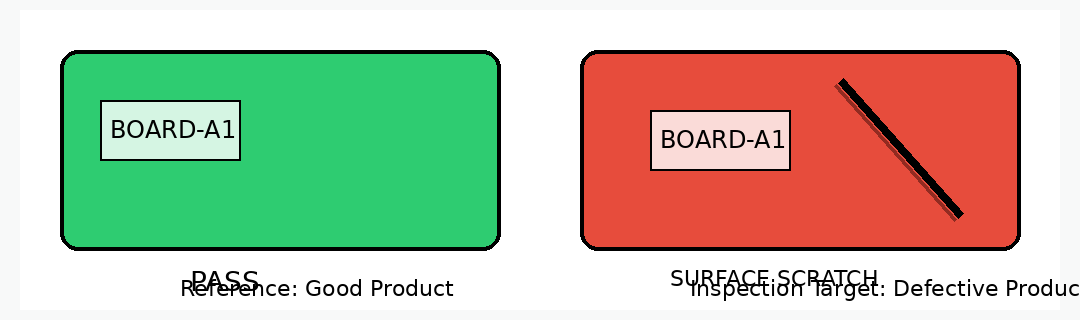

## Quality Inspection Report — BOARD-A1

---

### 1. 🔴 Overall Verdict: **FAIL**

This unit does **not meet acceptable quality standards** and should be flagged for review.

---

### 2. Observed Issues

| # | Issue | Location | Description |
|---|-------|----------|-------------|
| 1 | **Surface Scratch** | Right-center of board | Deep, diagonal scratch running approximately 45° across the surface |
| 2 | **Color Consistency** | General surface | Red substrate appears uniform — **no discoloration noted** ✅ |
| 3 | **Alignment** | Label "BOARD-A1" | Label appears slightly off-center (positioned left) — within tolerance, but notable |

---

### 3. Severity Assessment

| Defect | Severity Level |
|--------|---------------|
| Diagonal surface scratch | 🔴 **HIGH** — visually significant, potential structural compromise |
| Label positioning | 🟡 **LOW** — cosmetic only |

---

### 4. Recommended Action

- 🛑 **Remove unit from production line immediately**
- 🔍 **Inspect adjacent units** (BOAR

In [3]:
good_product = Image.new("RGB", (520, 300), "white")
good_draw = ImageDraw.Draw(good_product)
good_draw.rounded_rectangle((40, 40, 480, 240), radius=18, fill="#2ECC71", outline="black", width=4)
good_draw.rectangle((80, 90, 220, 150), fill="#D5F5E3", outline="black", width=2)
good_draw.text((90, 105), "BOARD-A1", fill="black", font=get_font(24))
good_draw.text((170, 255), "PASS", fill="black", font=get_font(28))

defective_product = Image.new("RGB", (520, 300), "white")
defect_draw = ImageDraw.Draw(defective_product)
defect_draw.rounded_rectangle((40, 40, 480, 240), radius=18, fill="#E74C3C", outline="black", width=4)
defect_draw.rectangle((110, 100, 250, 160), fill="#FADBD8", outline="black", width=2)
defect_draw.text((120, 115), "BOARD-A1", fill="black", font=get_font(24))
defect_draw.line((300, 70, 420, 205), fill="black", width=8)
defect_draw.line((295, 75, 415, 210), fill="#922B21", width=3)
defect_draw.text((130, 255), "SURFACE SCRATCH", fill="black", font=get_font(22))

good_path = save_image(good_product, "02-good-product.png")
defective_path = save_image(defective_product, "03-defective-product.png")

preview = Image.new("RGB", (1080, 320), "#F8F9F9")
preview.paste(good_product, (20, 10))
preview.paste(defective_product, (540, 10))
preview_draw = ImageDraw.Draw(preview)
preview_draw.text((180, 275), "Reference: Good Product", fill="black", font=get_font(22))
preview_draw.text((690, 275), "Inspection Target: Defective Product", fill="black", font=get_font(22))
preview_path = save_image(preview, "04-quality-preview.png")

display(IPImage(filename=str(preview_path)))

defective_bytes = pil_to_png_bytes(defective_product)
inspection_prompt = """
You are a quality inspector. Examine this product image.
Check for:
- surface defects
- color consistency
- alignment issues

Return your findings in this format:
1. Overall verdict
2. Observed issues
3. Severity
4. Recommended action
"""

message = Message(
    role="user",
    contents=[
        Content.from_data(data=defective_bytes, media_type="image/png"),
        Content.from_text(inspection_prompt),
    ],
)

response = await agent.run(message, session=session)
print(response.text)


## 🌐 Images from URLs

Sometimes your images are already hosted — in blob storage, a monitoring dashboard, a CMS, or a public repository. In that case, `Content.from_uri()` lets Claude analyze the image directly from its URL.

This is like sending Claude a map link instead of mailing a printed photograph. Same destination, less handling.


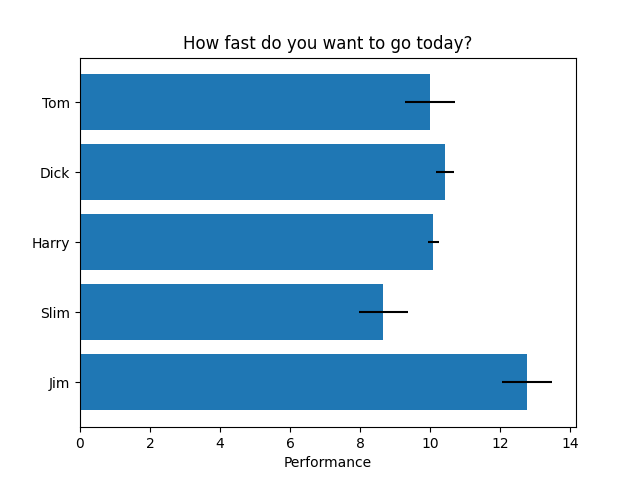

BadRequestError: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Unable to download the file. Please verify the URL and try again.'}, 'request_id': 'req_011CayEFb9iLKwooTF9BfJN6'}

In [4]:
image_url = "https://matplotlib.org/stable/_images/sphx_glr_barh_001.png"
image_bytes = requests.get(image_url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30).content

display(IPImage(data=image_bytes))

message = Message(
    role="user",
    contents=[
        Content.from_uri(image_url, media_type="image/png"),
        Content.from_text(
            "Analyze this chart. Explain what kind of chart it is, what patterns stand out, and what a business audience should notice first."
        ),
    ],
)

response = await agent.run(message, session=session)
print(response.text)


## 📄 Document Intelligence — Extracting Structured Data

PrecisionTech receives hundreds of invoices every month. Manually typing those values into an accounting system is slow, repetitive, and error-prone.

Claude can turn image pixels into **database-ready structure**. Think of it as giving Claude a pair of reading glasses and a spreadsheet template at the same time.

The trick is to ask for a schema, not just a summary.


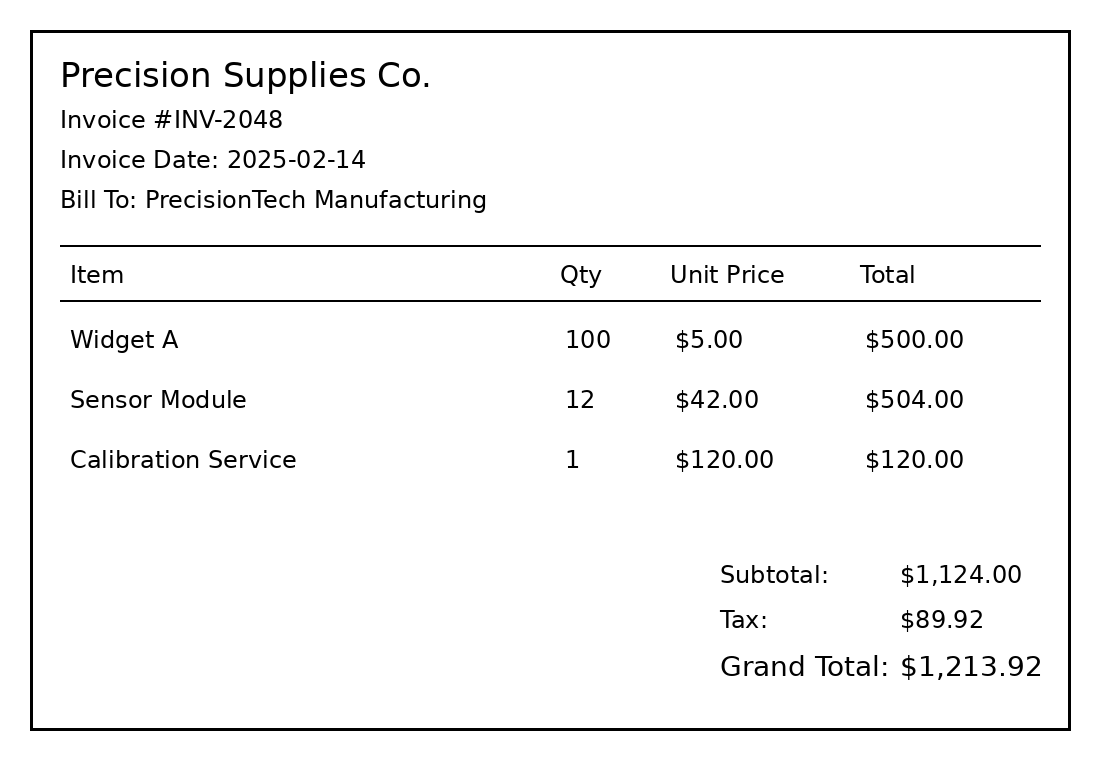

```json
{
  "vendor": "Precision Supplies Co.",
  "invoice_number": "INV-2048",
  "date": "2025-02-14",
  "bill_to": "PrecisionTech Manufacturing",
  "items": [
    {
      "name": "Widget A",
      "quantity": 100,
      "unit_price": 5.00,
      "total": 500.00
    },
    {
      "name": "Sensor Module",
      "quantity": 12,
      "unit_price": 42.00,
      "total": 504.00
    },
    {
      "name": "Calibration Service",
      "quantity": 1,
      "unit_price": 120.00,
      "total": 120.00
    }
  ],
  "subtotal": 1124.00,
  "tax": 89.92,
  "grand_total": 1213.92
}
```


In [5]:
invoice_image = Image.new("RGB", (1100, 760), "white")
draw = ImageDraw.Draw(invoice_image)

draw.rectangle((30, 30, 1070, 730), outline="black", width=3)
draw.text((60, 55), "Precision Supplies Co.", fill="black", font=get_font(34))
draw.text((60, 105), "Invoice #INV-2048", fill="black", font=get_font(24))
draw.text((60, 145), "Invoice Date: 2025-02-14", fill="black", font=get_font(24))
draw.text((60, 185), "Bill To: PrecisionTech Manufacturing", fill="black", font=get_font(24))

draw.line((60, 245, 1040, 245), fill="black", width=2)
draw.text((70, 260), "Item", fill="black", font=get_font(24))
draw.text((560, 260), "Qty", fill="black", font=get_font(24))
draw.text((670, 260), "Unit Price", fill="black", font=get_font(24))
draw.text((860, 260), "Total", fill="black", font=get_font(24))
draw.line((60, 300, 1040, 300), fill="black", width=2)

rows = [
    ("Widget A", "100", "$5.00", "$500.00"),
    ("Sensor Module", "12", "$42.00", "$504.00"),
    ("Calibration Service", "1", "$120.00", "$120.00"),
]

y = 325
for item, qty, unit_price, total in rows:
    draw.text((70, y), item, fill="black", font=get_font(24))
    draw.text((565, y), qty, fill="black", font=get_font(24))
    draw.text((675, y), unit_price, fill="black", font=get_font(24))
    draw.text((865, y), total, fill="black", font=get_font(24))
    y += 60

summary_y = 560
draw.text((720, summary_y), "Subtotal:", fill="black", font=get_font(24))
draw.text((900, summary_y), "$1,124.00", fill="black", font=get_font(24))
draw.text((720, summary_y + 45), "Tax:", fill="black", font=get_font(24))
draw.text((900, summary_y + 45), "$89.92", fill="black", font=get_font(24))
draw.text((720, summary_y + 90), "Grand Total:", fill="black", font=get_font(28))
draw.text((900, summary_y + 90), "$1,213.92", fill="black", font=get_font(28))

invoice_path = save_image(invoice_image, "05-mock-invoice.png")
invoice_bytes = pil_to_png_bytes(invoice_image)

display(IPImage(filename=str(invoice_path)))

prompt = """
Extract all data from this invoice.
Return valid JSON only with fields:
- vendor
- invoice_number
- date
- bill_to
- items (name, quantity, unit_price, total)
- subtotal
- tax
- grand_total
"""

message = Message(
    role="user",
    contents=[
        Content.from_data(data=invoice_bytes, media_type="image/png"),
        Content.from_text(prompt),
    ],
)

response = await agent.run(message, session=session)
print(response.text)


## 🔀 Multi-Image Comparison

Sometimes you don't want Claude to inspect one image — you want it to compare two or more.

This is useful for:

- before vs. after inspections
- reference unit vs. suspect unit
- version A vs. version B of a document or dashboard

You can send multiple `Content` items in one `Message`, which gives Claude a side-by-side visual conversation to work with.


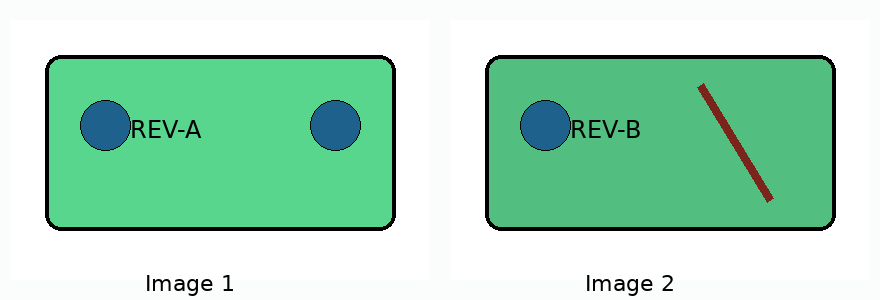

## Comparative Product Analysis — REV-A vs REV-B

---

### Side-by-Side Differences

| Feature | REV-A | REV-B |
|--------|-------|-------|
| **Label** | REV-A | REV-B |
| **Mounting holes** | ✅ Two blue circles (left + right) | ⚠️ One blue circle (left only) |
| **Surface condition** | ✅ Clean, no marks | 🔴 Diagonal scratch/mark (right side) |
| **Overall appearance** | ✅ Uniform, intact | ❌ Compromised |

---

### 🔴 Defective Unit: **REV-B**

#### Reasons:
1. **Missing Component/Feature** — The right-side mounting hole present in REV-A is **absent in REV-B**. This could indicate:
   - A missing drilled hole (manufacturing omission)
   - A filled or obscured hole (assembly error)

2. **Surface Scratch** — A prominent **diagonal dark-red scratch** runs across the right portion of the board — consistent with mechanical damage during handling or processing

---

### 🔍 Quality Verdict

| Unit | Status | Action |
|------|--------|--------|
| REV-A | ✅ **PASS** | Clear for use |
| REV-B | 🔴

In [6]:
product_a = Image.new("RGB", (420, 260), "white")
a_draw = ImageDraw.Draw(product_a)
a_draw.rounded_rectangle((35, 35, 385, 210), radius=16, fill="#58D68D", outline="black", width=4)
a_draw.ellipse((70, 80, 120, 130), fill="#1F618D", outline="black")
a_draw.ellipse((300, 80, 350, 130), fill="#1F618D", outline="black")
a_draw.text((120, 95), "REV-A", fill="black", font=get_font(24))

product_b = Image.new("RGB", (420, 260), "white")
b_draw = ImageDraw.Draw(product_b)
b_draw.rounded_rectangle((35, 35, 385, 210), radius=16, fill="#52BE80", outline="black", width=4)
b_draw.ellipse((70, 80, 120, 130), fill="#1F618D", outline="black")
b_draw.text((120, 95), "REV-B", fill="black", font=get_font(24))
b_draw.line((250, 65, 320, 180), fill="#7B241C", width=7)

product_a_path = save_image(product_a, "06-product-a.png")
product_b_path = save_image(product_b, "07-product-b.png")

side_by_side = Image.new("RGB", (880, 300), "#FBFCFC")
side_by_side.paste(product_a, (10, 20))
side_by_side.paste(product_b, (450, 20))
label_draw = ImageDraw.Draw(side_by_side)
label_draw.text((145, 270), "Image 1", fill="black", font=get_font(22))
label_draw.text((585, 270), "Image 2", fill="black", font=get_font(22))
side_by_side_path = save_image(side_by_side, "08-side-by-side-comparison.png")

display(IPImage(filename=str(side_by_side_path)))

message = Message(
    role="user",
    contents=[
        Content.from_data(data=pil_to_png_bytes(product_a), media_type="image/png"),
        Content.from_data(data=pil_to_png_bytes(product_b), media_type="image/png"),
        Content.from_text(
            "Compare these two product images. List the differences you notice, identify which image appears defective, and explain why."
        ),
    ],
)

response = await agent.run(message, session=session)
print(response.text)


## 🎯 Prompt Engineering for Vision — Getting Better Results

Just like with text, **how you ask matters enormously**.

A vague prompt like *"Describe this."* often gives you a vague answer.
A specific prompt like *"identify all text, extract totals, and flag any anomalies"* gives you something a workflow can actually use.

Think of prompting like briefing a specialist:

- vague brief → casual observation
- precise brief → usable deliverable

Let's use the same invoice image twice and compare the difference.


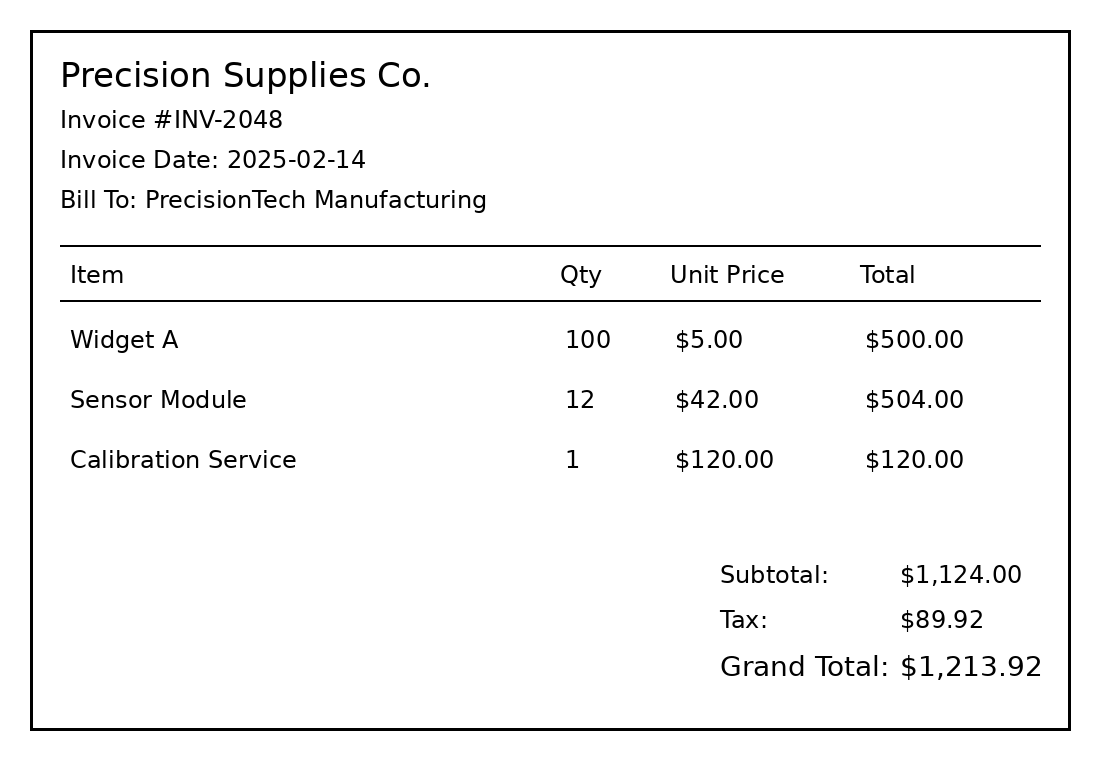

=== Vague prompt response ===
## Invoice Summary — Precision Supplies Co.

---

### Header Information
| Field | Value |
|-------|-------|
| **Vendor** | Precision Supplies Co. |
| **Invoice #** | INV-2048 |
| **Date** | 2025-02-14 |
| **Bill To** | PrecisionTech Manufacturing |

---

### Line Items

| Item | Qty | Unit Price | Total |
|------|-----|-----------|-------|
| Widget A | 100 | $5.00 | $500.00 |
| Sensor Module | 12 | $42.00 | $504.00 |
| Calibration Service | 1 | $120.00 | $120.00 |

---

### Financials
| | |
|-|--|
| **Subtotal** | $1,124.00 |
| **Tax** | $89.92 |
| **Grand Total** | **$1,213.92** |

---

### ⚠️ Notable Observation
> The tax rate applied is approximately **8%** — worth verifying against current applicable tax jurisdiction rates for **PrecisionTech Manufacturing's** procurement records and compliance requirements.

This is a clean, straightforward **supplier invoice** with no missing fields or visible anomalies.

=== Specific prompt response ===
## Full Inv

In [7]:
display(IPImage(filename=str(invoice_path)))

vague_message = Message(
    role="user",
    contents=[
        Content.from_data(data=invoice_bytes, media_type="image/png"),
        Content.from_text("Describe this."),
    ],
)

specific_message = Message(
    role="user",
    contents=[
        Content.from_data(data=invoice_bytes, media_type="image/png"),
        Content.from_text(
            "Read this invoice carefully. Extract vendor, invoice number, date, bill-to name, every line item, subtotal, tax, grand total, and mention if any arithmetic looks inconsistent."
        ),
    ],
)

vague_response = await agent.run(vague_message, session=session)
specific_response = await agent.run(specific_message, session=session)

print("=== Vague prompt response ===")
print(vague_response.text)
print()
print("=== Specific prompt response ===")
print(specific_response.text)


## 🎯 Try It Yourself

Now it's your turn. Try one of these mini-experiments:

1. **Analyze a real photo** from your phone and ask Claude to describe defects, layout, or safety issues.
2. **Extract data from a screenshot** of a spreadsheet, dashboard, or receipt.
3. **Compare two product photos** and ask for a pass/fail recommendation.

### Key Takeaways

- Multi-modal prompting lets Claude work with **images + instructions together**
- `Content.from_data()` is great for files, uploads, cameras, and generated images
- `Content.from_uri()` is convenient when images are already hosted
- Specific prompts create **workflow-ready outputs** like JSON, checklists, and recommendations
- The same model can help both the **factory floor** and the **finance desk**

If text-only prompting is like talking to an expert over email, multi-modal prompting is like handing that expert the actual photo, diagram, or invoice and saying: *"Tell me what matters."*
